In [1]:
include("PermBasis.jl")
include("PlotSetup.jl")
include("MonteCarloMF.jl")
using PyPlot
using DifferentialEquations
using JLD2

legend_kwargs = (
    fontsize=12,
    framealpha=0.9,
    borderpad=0.3,
    labelspacing=0.3,
    handlelength=2.0
)

(fontsize = 12, framealpha = 0.9, borderpad = 0.3, labelspacing = 0.3, handlelength = 2.0)

In [135]:
function generate_dephasing_finiteN_scan(;
    Ns = Int.(round.(10 .^ range(4, 7.0, 50))),
    rs = [0.1, 0.95, 1.05],
    N_traj = 800,
    g = 0.0,
    time_factor = 16.0,
    outfile = "../plot_data/dephasing_finiteN_scan.jld2",
    save_progress = true,
)
    mc_intens = zeros(length(rs), length(Ns))
    mc_t = zeros(length(rs), length(Ns))

    for (i, r) in enumerate(rs)
        println("Finite-N scan: r = $r [$i/$(length(rs))]")
        for (j, N) in enumerate(Ns)
            println("  N = $N [$j/$(length(Ns))]")

            params = Dict(
                "global_decay" => 1.0,
                "global_pump" => 0.0,
                "local_pump" => 0.0,
                "local_dephasing" => r * N,
                "local_decay" => g * N / log(N),
            )

            imc, tmc = mc_data(N, params, N_traj; time_factor=time_factor)

            mc_intens[i, j] = imc
            mc_t[i, j] = tmc
        end

        if save_progress
            jldsave(outfile;
                rs = rs,
                Ns = Ns,
                N_traj = N_traj,
                g = g,
                time_factor = time_factor,
                mc_intens = mc_intens,
                mc_t = mc_t,
            )
        end
    end

    jldsave(outfile;
        rs = rs,
        Ns = Ns,
        N_traj = N_traj,
        g = g,
        time_factor = time_factor,
        mc_intens = mc_intens,
        mc_t = mc_t,
    )
end

function plot_dephasing_panel_c!(ax, d)
    @show data
    rs2 = d["rs"]
    Ns2 = d["Ns"]
    mc_intens2 = d["mc_intens"]

    for j in eachindex(rs2)
        ax.scatter(Ns2, mc_intens2[j, :] ./ Ns2.^2 ./ 0.2, label="\$g_\\xi=$(rs2[j])\$")
    end

    ax.plot(Ns2, 110 ./ Ns2, color="k", label=L"\mathcal O(1/N)")
    ax.plot(Ns2, 140 ./ Ns2 .+ (1 - rs2[1])^2, color="k", linestyle="solid")
    ax.plot(Ns2, 140 ./ Ns2 .+ (1 - rs2[2])^2, color="k", linestyle="solid")

    ax.legend(;legend_kwargs...)
    ax.set_yscale("log")
    ax.set_ylabel(L"I/I(g_\xi=0)")
    ax.set_xlabel(L"N")

    return ax
end


function plot_dephasing_panel_d!(ax, d)
    rs2 = d["rs"]
    Ns2 = d["Ns"]
    mc_intens2 = d["mc_intens"]

    for j in eachindex(rs2)
        Is = mc_intens2[j, :]
        x = log.(Ns2)
        y = log.(Is)
        A = [ones(length(x)) x]
        coeff = A \ y
        c, b = coeff
        a = exp(c)

        ax.scatter(Ns2, Is, label="\$g_\\xi=$(rs2[j])\\,(\\alpha=$(round(b, digits=2)))\$")
        ax.plot(Ns2, a .* Ns2.^b, linestyle="-")
    end

    ax.legend(;legend_kwargs...)
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_ylabel(L"I/\Gamma")
    ax.set_xlabel(L"N")

    return ax
end

function plot_fig3c!(ax, data; colors_scatter = ["red", "blue"], colors_mf = ["orange", "cyan"])
    Ns = data["Ns"]
    rs = data["rs"]
    mc_t = data["mc_t"]

    @assert length(rs) >= 2
    @assert length(colors_scatter) >= 2
    @assert length(colors_mf) >= 2

    for j in 1:2
        ax.scatter(
            Ns,
            mc_t[j, :],
            color = colors_scatter[j],
            label = "MC \$g_\\xi=$(rs[j])\$"
        )

        ax.plot(
            Ns,
            log.(Ns) ./ Ns ./ (1.0 .- rs[j]),
            color = colors_mf[j],
            linestyle = "solid",
            label = "MF \$g_\\xi=$(rs[j])\$"
        )
    end

    ax.legend(; legend_kwargs...)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(L"N")
    ax.set_ylabel(L"t_\star")

    return ax
end

using LsqFit

# --------------------------------------------------
# fit helpers
# --------------------------------------------------

function fit_A_plus_B_over_N(Ns, ys; Nmin=1e5)
    x = Float64.(Ns)
    y = Float64.(ys)

    mask = x .>= Nmin
    @assert any(mask) "No data points satisfy N >= Nmin."

    xfit = x[mask]
    yfit = y[mask]

    model(x, p) = p[1] .+ p[2] ./ x
    p0 = [yfit[end], 1.0]

    fit = curve_fit(model, xfit, yfit, p0)
    A, B = fit.param

    return (
        A = A,
        B = B,
        fit = fit,
        mask = mask,
        model = model,
        xfit = xfit,
        yfit = yfit,
    )
end

function fit_B_over_N(Ns, ys; Nmin=1e5)
    x = Float64.(Ns)
    y = Float64.(ys)

    mask = x .>= Nmin
    @assert any(mask) "No data points satisfy N >= Nmin."

    xfit = x[mask]
    yfit = y[mask]

    model(x, p) = p[1] ./ x
    p0 = [1.0]

    fit = curve_fit(model, xfit, yfit, p0)
    B = fit.param[1]

    return (
        B = B,
        fit = fit,
        mask = mask,
        model = model,
        xfit = xfit,
        yfit = yfit,
    )
end

# --------------------------------------------------
# representative plotting functions
# --------------------------------------------------

function plot_dephasing_panel_c_below_fit!(ax, d; which=2, Nmin=1e5)
    rs = d["rs"]
    Ns = d["Ns"]
    mc_intens = d["mc_intens"]

    below_inds = findall(<(1), rs)
    @assert length(below_inds) >= which "Need at least $which values with g_xi < 1."
    j = below_inds[which]

    r = rs[j]
    x = Float64.(Ns)
    y = Float64.(mc_intens[j, :] ./ Ns.^2)

    fitdata = fit_A_plus_B_over_N(x, y; Nmin=Nmin)
    A, B = fitdata.A, fitdata.B
    mask = fitdata.mask
    model = fitdata.model

    ax.scatter(
        x, y,
        label = "\$g_\\xi=$(r)\$"
    )

    ax.scatter(
        x[mask], y[mask],
        facecolor = "red",
        edgecolors = "k",
        linewidths = 0.8,
        zorder = 3
    )

    xline = collect(range(minimum(x[mask]), maximum(x), length=400))
    yline = model(xline, [A, B])

    ax.plot(
        xline, yline,
        color = "k",
        linestyle = "-",
        linewidth = 1.8,
        label = "\$A+B/N\$ fit",
        zorder = 10
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(L"N")
    ax.set_ylabel(L"I_{\max}/N^2")
    ax.legend(; legend_kwargs...)

    return (
        ax = ax,
        r = r,
        A = A,
        B = B,
        fit = fitdata.fit,
        mask = mask,
    )
end

function plot_dephasing_panel_c_above_fit!(ax, d; which=2, Nmin=1e5)
    rs = d["rs"]
    Ns = d["Ns"]
    mc_intens = d["mc_intens"]

    above_inds = findall(>(1), rs)
    @assert length(above_inds) >= which "Need at least $which values with g_xi > 1."
    j = above_inds[which]

    r = rs[j]
    x = Float64.(Ns)
    y = Float64.(mc_intens[j, :] ./ Ns.^2)

    fitdata = fit_B_over_N(x, y; Nmin=Nmin)
    B = fitdata.B
    mask = fitdata.mask
    model = fitdata.model

    ax.scatter(
        x, y,
        label = "\$g_\\xi=$(r)\$"
    )

    ax.scatter(
        x[mask], y[mask],
        facecolor = "red",
        edgecolors = "k",
        linewidths = 0.8,
        zorder = 3
    )

    xline = collect(range(minimum(x[mask]), maximum(x), length=400))
    yline = model(xline, [B])

    ax.plot(
        xline, yline,
        color = "k",
        linestyle = "-",
        linewidth = 1.8,
        label = "\$B/N\$ fit",
        zorder = 10
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(L"N")
    ax.set_ylabel(L"I_{\max}/N^2")
    ax.legend(; legend_kwargs...)

    return (
        ax = ax,
        r = r,
        B = B,
        fit = fitdata.fit,
        mask = mask,
    )
end

generate_dephasing_finiteN_scan (generic function with 1 method)

In [ ]:
generate_dephasing_finiteN_scan()

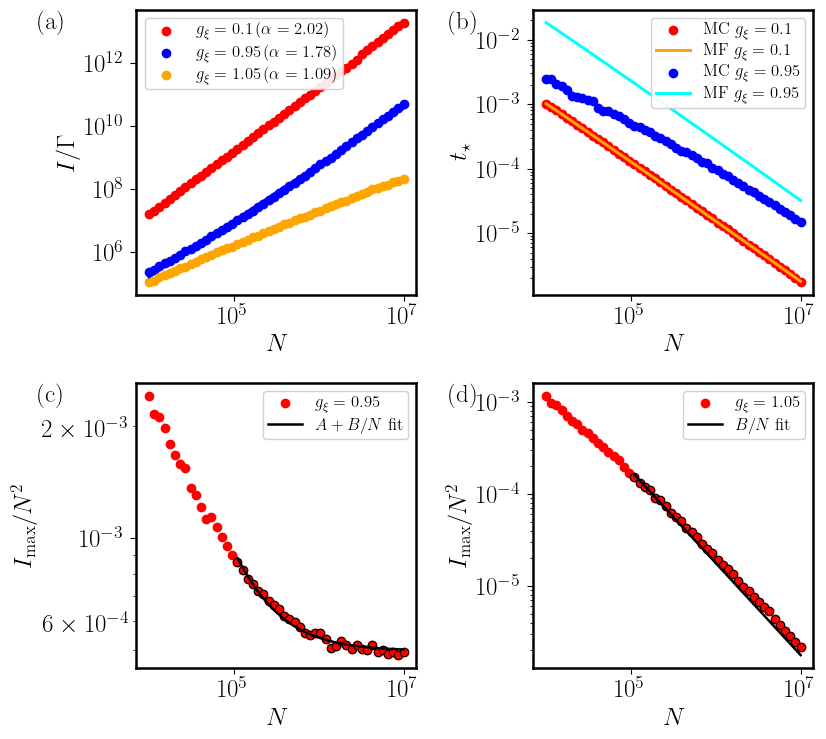

In [134]:


fig, axes = subplots(ncols = 2, nrows = 2, figsize = 2.0 .* latex_plot_setup(ratio=0.9, scale=1.8))


data = load("../plot_data/dephasing_finiteN_scan.jld2")
plot_dephasing_panel_d!(axes[1,1], data)
plot_fig3c!(axes[1,2], data)
plot_dephasing_panel_c_below_fit!(axes[2,1], data; which = 2)
plot_dephasing_panel_c_above_fit!(axes[2,2], data; which = 1)

tight_layout()
axes[1,1].text(-0.35, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.3, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[2,1].text(-0.35, 1.0, "(c)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.3, 1.0, "(d)", transform=axes[2,2].transAxes, va="top")

savefig("../data/fig3.pdf", bbox_inches = "tight")